# YOLO26 Instance Segmentation: Pixel-Perfect AI at Real-Time Speed

https://learnopencv.com/yolo26-instance-segmentation-pixel-perfect-ai-at-real-time-speed/

WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26n-seg.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1077)>


######################################################                    75.1%


image 1/1 /Users/aruvins/projects/AI Projects/YOLO26_Instance_Segmentation/images/common_objects.jpg: 352x640 1 handbag, 1 cup, 1 chair, 2 potted plants, 1 laptop, 1 mouse, 1 vase, 26.7ms
Speed: 1.0ms preprocess, 26.7ms inference, 0.9ms postprocess per image at shape (1, 3, 352, 640)
Objects detected: 8


######################################################################## 100.0%


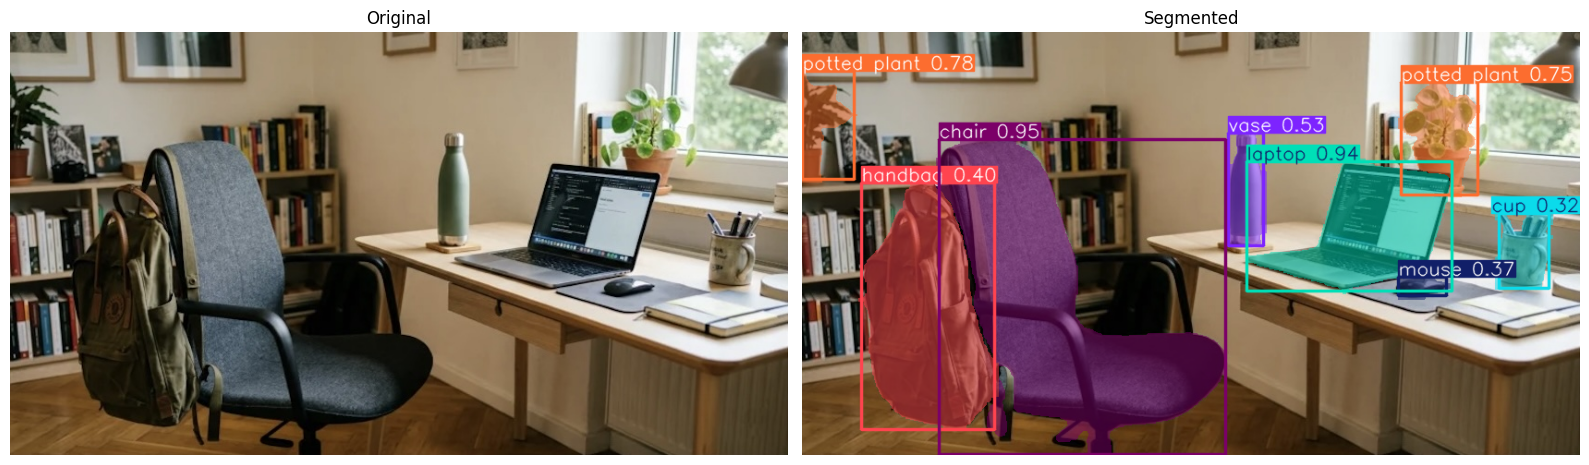

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
  
# Load pretrained YOLO26 segmentation model
model = YOLO("yolo26n-seg.pt")
  
# Run inference
results = model("images/common_objects.jpg", conf=0.25, iou=0.45)

# Access results
result = results[0]
print(f"Objects detected: {len(result.boxes)}")
  
if result.masks is not None:
    polygon_coords = result.masks.xy      # mask as polygon
    mask_matrix    = result.masks.data     # mask as matrix (N x H x W)
  
# Visualize -- original vs segmented side by side
original  = cv2.cvtColor(result.orig_img, cv2.COLOR_BGR2RGB)
annotated = cv2.cvtColor(result.plot(),    cv2.COLOR_BGR2RGB)
  
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(original);  axes[0].set_title("Original");   axes[0].axis("off")
axes[1].imshow(annotated); axes[1].set_title("Segmented");  axes[1].axis("off")
plt.tight_layout(); plt.show()